# Employee Promotion Prediction: Impact of Discretization and Binarization

## Project Overview
This project explores the impact of **Discretization** and **Binarization** as feature engineering techniques on a machine learning model.

The dataset contains employee-related information such as age, years at the company, monthly salary, performance score, training hours, projects completed, and overtime hours. The objective is to predict whether an employee will receive a **promotion**.

### Objectives

- Understand and apply **Discretization** to continuous numerical features.
- Understand and apply **Binarization** using meaningful thresholds.
- Use **ColumnTransformer** to apply transformations to selected features.
- Train a **Logistic Regression** model before and after feature transformation.
- Compare model accuracy to evaluate the impact of these feature engineering techniques.

### Experiment

The model's performance will be evaluated under four different conditions:

1. **Original Features**
2. **Discretization**
3. **Binarization**
4. **Discretization + Binarization**

This comparison will help determine whether transforming numerical features into discrete ranges or binary indicators improves the predictive performance of the model.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [47]:
data=pd.read_csv('employee_promotion.csv')
data

,Age,Years_At_Company,Monthly_Salary,Performance_Score,Training_Hours,Projects_Completed,Overtime_Hours,Promotion
0,60,2,83200,5.8,39,7,9,Yes
1,50,5,76900,5.5,20,1,4,No
2,36,3,67900,5.8,41,6,12,No
3,29,8,101300,5.4,28,10,19,Yes
4,42,10,104800,7.3,33,5,10,No
...,...,...,...,...,...,...,...,...
195,30,6,72700,9.2,48,3,4,Yes
196,27,7,93000,7.7,65,9,22,Yes
197,37,2,91400,7.7,28,4,4,No
198,50,7,78800,8.0,41,10,15,Yes


In [48]:
data.sample(5)

,Age,Years_At_Company,Monthly_Salary,Performance_Score,Training_Hours,Projects_Completed,Overtime_Hours,Promotion
183,25,5,75600,4.1,46,6,10,Yes
31,28,3,51300,6.3,38,5,2,No
189,55,2,46500,7.8,30,9,9,Yes
64,35,4,83200,6.9,47,4,7,No
66,42,6,71600,8.5,43,4,16,Yes


UNDERSTANDING THE DATA

In [49]:
data.shape

(200, 8)

In [50]:
data.describe()

,Age,Years_At_Company,Monthly_Salary,Performance_Score,Training_Hours,Projects_Completed,Overtime_Hours
count,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000
mean,41.045000,4.92500,78789.500000,6.937000,39.575000,5.145000,12.81500
std,11.826339,2.24378,16443.625019,1.378343,12.831509,2.390092,5.94115
min,22.000000,1.00000,27800.000000,3.100000,2.000000,1.000000,0.00000
25%,30.000000,3.00000,70050.000000,6.000000,32.000000,3.000000,9.00000
50%,42.500000,5.00000,78800.000000,6.900000,39.000000,5.000000,13.00000
75%,51.000000,6.00000,89575.000000,7.800000,48.000000,7.000000,17.00000
max,60.000000,11.00000,116700.000000,10.000000,79.000000,12.000000,30.00000


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 200 non-null    int64  
 1   Years_At_Company    200 non-null    int64  
 2   Monthly_Salary      200 non-null    int64  
 3   Performance_Score   200 non-null    float64
 4   Training_Hours      200 non-null    int64  
 5   Projects_Completed  200 non-null    int64  
 6   Overtime_Hours      200 non-null    int64  
 7   Promotion           200 non-null    object 
dtypes: float64(1), int64(6), object(1)
memory usage: 12.6+ KB


In [52]:
#Chcecking for missing values
data.isnull().sum()

Age                   0
Years_At_Company      0
Monthly_Salary        0
Performance_Score     0
Training_Hours        0
Projects_Completed    0
Overtime_Hours        0
Promotion             0
dtype: int64

In [53]:
#Checking for duplicates
print(data.duplicated().sum())

0


In [54]:
#Checking the target column
data['Promotion'].value_counts()

Promotion
No     122
Yes     78
Name: count, dtype: int64

SEPERATE x AND y

In [55]:
x=data.drop('Promotion',axis=1)

In [56]:
x.head()

,Age,Years_At_Company,Monthly_Salary,Performance_Score,Training_Hours,Projects_Completed,Overtime_Hours
0,60,2,83200,5.8,39,7,9
1,50,5,76900,5.5,20,1,4
2,36,3,67900,5.8,41,6,12
3,29,8,101300,5.4,28,10,19
4,42,10,104800,7.3,33,5,10


In [57]:
y=data['Promotion']
y=y.map({'Yes':1,'No':0})

In [58]:
y.head(10)

0    1
1    0
2    0
3    1
4    0
5    0
6    0
7    0
8    0
9    1
Name: Promotion, dtype: int64

TRAIN-TEST SPLIT

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [60]:
x_train.shape

(160, 7)

In [61]:
x_test.shape

(40, 7)

PART A — BASELINE MODEL:
Before applying any discretization or binarization

In [62]:
lr=LogisticRegression(max_iter=1000)

In [63]:
lr.fit(x_train,y_train)

C:\Users\alekh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [64]:
y_pred=lr.predict(x_test)

In [65]:
accuracy_before=accuracy_score(y_test,y_pred)
print("Accuracy Before Discretization =",accuracy_before)

Accuracy Before Discretization = 0.575


PART B — DISCRETIZATION

In [66]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [67]:
discretized_columns=['Age','Years_At_Company','Monthly_Salary']
remaining_columns=['Performance_Score','Training_Hours','Projects_Completed','Overtime_Hours']

In [68]:
#Applying Discretization 
trf=ColumnTransformer(transformers=[(
    "discrete",KBinsDiscretizer(n_bins=4,encode='ordinal',strategy='quantile'),discretized_columns)],remainder='passthrough')

In [69]:
x_train_transformed=trf.fit_transform(x_train) #transform training data
x_test_transformed=trf.transform(x_test) #transform the test data

In [70]:
x_train_transformed

array([[ 0.,  1.,  2., ..., 47.,  2., 12.],
       [ 1.,  0.,  3., ..., 28.,  4.,  4.],
       [ 1.,  3.,  1., ..., 48.,  5., 15.],
       ...,
       [ 1.,  3.,  2., ..., 34.,  2., 23.],
       [ 2.,  3.,  3., ..., 25.,  3., 25.],
       [ 2.,  2.,  1., ..., 34.,  5., 15.]], shape=(160, 7))

In [71]:
#Converting to dataframe
x_train_discrete=pd.DataFrame(x_train_transformed,columns=discretized_columns+remaining_columns,index=x_train.index)

In [72]:
x_train_discrete.head(10)

,Age,Years_At_Company,Monthly_Salary,Performance_Score,Training_Hours,Projects_Completed,Overtime_Hours
79,0.0,1.0,2.0,7.5,47.0,2.0,12.0
197,1.0,0.0,3.0,7.7,28.0,4.0,4.0
38,1.0,3.0,1.0,7.2,48.0,5.0,15.0
24,2.0,1.0,0.0,6.6,58.0,3.0,7.0
122,3.0,2.0,3.0,8.6,51.0,8.0,9.0
195,1.0,3.0,1.0,9.2,48.0,3.0,4.0
29,0.0,2.0,2.0,7.8,33.0,7.0,1.0
19,0.0,1.0,0.0,6.8,24.0,6.0,3.0
143,2.0,1.0,2.0,7.2,48.0,3.0,13.0
86,3.0,3.0,2.0,5.4,30.0,5.0,17.0


In [73]:
x_test_discrete=pd.DataFrame(x_test_transformed,columns=discretized_columns+remaining_columns,index=x_test.index)

In [74]:
x_test_discrete.head(10)

,Age,Years_At_Company,Monthly_Salary,Performance_Score,Training_Hours,Projects_Completed,Overtime_Hours
95,3.0,3.0,0.0,6.6,32.0,3.0,16.0
15,0.0,3.0,3.0,8.0,46.0,2.0,10.0
30,3.0,1.0,1.0,5.3,34.0,5.0,14.0
158,2.0,3.0,3.0,5.7,34.0,3.0,13.0
128,1.0,0.0,1.0,6.3,47.0,2.0,8.0
115,1.0,1.0,3.0,7.3,30.0,2.0,7.0
69,2.0,0.0,1.0,7.8,38.0,4.0,0.0
170,0.0,1.0,0.0,7.4,50.0,4.0,14.0
174,3.0,3.0,1.0,7.1,43.0,10.0,12.0
45,0.0,1.0,1.0,7.5,19.0,3.0,10.0


In [75]:
lr_discrete=LogisticRegression(max_iter=1000)

In [76]:
lr_discrete.fit(x_train_discrete,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [77]:
y_pred_discrete=lr_discrete.predict(x_test_discrete)

In [78]:
accuracy_discrete=accuracy_score(y_pred_discrete,y_test)
print("Accuracy After Discretization =",accuracy_discrete)

Accuracy After Discretization = 0.625


PART C — BINARIZATION

In [129]:
x_train_binary=x_train.copy()
x_test_binary=x_test.copy()

In [130]:
#Binarizing Performance Score
x_train_binary['Performance_Score']=(x_train_binary['Performance_Score']>=7).astype(int)
x_test_binary['Performance_Score']=(x_test_binary['Performance_Score']>=7).astype(int)

In [131]:
#Binarizing Training Hours
x_train_binary['Training_Hours']=(x_train_binary['Training_Hours']>=30).astype(int)
x_test_binary['Training_Hours']=(x_test_binary['Training_Hours']>=30).astype(int)

In [132]:
x_train_binary[['Performance_Score','Training_Hours']].head(10)

,Performance_Score,Training_Hours
79,1,1
197,1,0
38,1,1
24,0,1
122,1,1
195,1,1
29,1,1
19,0,0
143,1,1
86,0,1


In [133]:
lr_binary=LogisticRegression(max_iter=1000)

In [134]:
lr_binary.fit(x_train_binary,y_train)

C:\Users\alekh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [135]:
y_pred_binary=lr_binary.predict(x_test_binary)

In [136]:
accuracy_binary=accuracy_score(y_pred_binary,y_test)
print("Accuracy after Binarization =",accuracy_binary)

Accuracy after Binarization = 0.55


PART D — BOTH DISCRETIZATION + BINARIZATION

In [104]:
x_train_both=x_train.copy()
x_test_both=x_test.copy()

In [105]:
#Applying discretization
x_train_both=pd.DataFrame(x_train_transformed,columns=x_train.columns,index=x_train.index)
x_test_both=pd.DataFrame(x_test_transformed,columns=x_test.columns,index=x_test.index)

In [114]:
#Applying binarization on Performance_Score
x_train_both['Performance_Score']=(x_train['Performance_Score']>=7).astype(int)
x_test_both['Performance_Score']=(x_test['Performance_Score']>=7).astype(int)

In [115]:
#Applying binarization on Training_Hours
x_train_both['Training_Hours']=(x_train['Training_Hours']>=30).astype(int)
x_test_both['Training_Hours']=(x_test['Training_Hours']>=30).astype(int)

In [119]:
x_train_both.head(10)

,Age,Years_At_Company,Monthly_Salary,Performance_Score,Training_Hours,Projects_Completed,Overtime_Hours
79,0.0,1.0,2.0,1,1,2.0,12.0
197,1.0,0.0,3.0,1,0,4.0,4.0
38,1.0,3.0,1.0,1,1,5.0,15.0
24,2.0,1.0,0.0,0,1,3.0,7.0
122,3.0,2.0,3.0,1,1,8.0,9.0
195,1.0,3.0,1.0,1,1,3.0,4.0
29,0.0,2.0,2.0,1,1,7.0,1.0
19,0.0,1.0,0.0,0,0,6.0,3.0
143,2.0,1.0,2.0,1,1,3.0,13.0
86,3.0,3.0,2.0,0,1,5.0,17.0


In [120]:
lr_both=LogisticRegression(max_iter=1000)

In [121]:
lr_both.fit(x_train_both,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [122]:
y_pred_both=lr_both.predict(x_test_both)

In [124]:
accuracy_both=accuracy_score(y_pred_both,y_test)
print("Accuracy after both DISCRETIZATION + BINARIZATION =",accuracy_both)

Accuracy after both DISCRETIZATION + BINARIZATION = 0.675


PART D - COMPARING ALL THE RESULTS

In [125]:
results = pd.DataFrame({
    "Technique": [
        "Original Features",
        "Discretization",
        "Binarization",
        "Discretization + Binarization"
    ],
    
    "Accuracy": [
        accuracy_before,
        accuracy_discrete,
        accuracy_binary,
        accuracy_both
    ]
})

In [126]:
results

,Technique,Accuracy
0,Original Features,0.575
1,Discretization,0.625
2,Binarization,0.550
3,Discretization + Binarization,0.675


In [127]:
results['Accuracy']=results['Accuracy']*100

In [128]:
results

,Technique,Accuracy
0,Original Features,57.5
1,Discretization,62.5
2,Binarization,55.0
3,Discretization + Binarization,67.5


PLOTTING THE COMPARISON

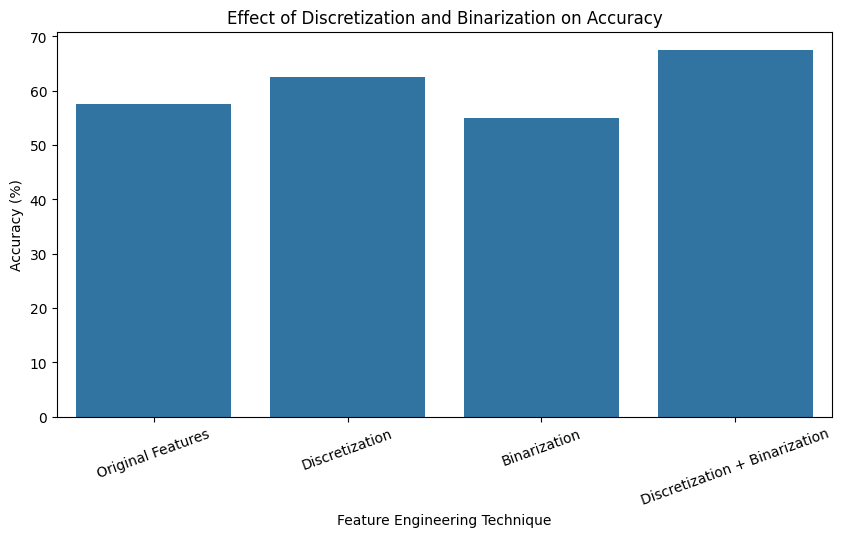

In [138]:
plt.figure(figsize=(10,5))
sns.barplot(data=results,x='Technique',y='Accuracy')

plt.title('Effect of Discretization and Binarization on Accuracy')
plt.xlabel('Feature Engineering Technique')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=20)

plt.show()

## Conclusion

1. **Baseline Performance:**  
   The Logistic Regression model achieved an accuracy of **57.5%** using the original numerical features, providing a baseline for evaluating the impact of feature transformations.

2. **Effect of Discretization:**  
   Discretization converted continuous features such as Age, Years at Company, and Monthly Salary into discrete bins. This helped evaluate whether representing numerical values as ranges could improve the model's performance.

3. **Effect of Binarization:**  
   Binarization converted Performance Score and Training Hours into binary features based on predefined thresholds. The accuracy decreased slightly to **55%**, indicating that simplifying these features resulted in some loss of information.

4. **Combined Feature Engineering:**  
   Applying both discretization and binarization allowed us to evaluate the combined effect of the two techniques on model performance and compare it against the original features.

5. **Overall Learning:**  
   The experiment demonstrates that feature engineering does not necessarily improve accuracy in every situation. The effectiveness of discretization and binarization depends on the dataset, selected features, and thresholds used.